In [33]:
import os
import json
import random
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split

import torchvision
from torchvision import transforms

print("torch:", torch.__version__)
print("torchvision:", torchvision.__version__)

torch: 2.10.0+cpu
torchvision: 0.25.0+cpu


In [34]:
def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

os.makedirs("artifacts/figures", exist_ok=True)

device: cpu


In [35]:
def accuracy_from_logits(logits: torch.Tensor, y_true: torch.Tensor) -> float:
    preds = torch.argmax(logits, dim = 1)
    return (preds == y_true).float().mean().item()

def plot_history(history: dict, title: str = "", isSave: bool = False, save_title: str = "untitled") -> None:
    epochs = np.arange(1, len(history["train_loss"]) + 1)

    plt.figure()
    plt.plot(epochs, history["train_loss"], label = "train_loss")
    plt.plot(epochs, history["val_loss"], label = "val_loss")
    plt.xlabel("epochs")
    plt.ylabel("loss")
    plt.title( (title + " (loss)") if title else "loss")
    plt.legend()
    plt.grid(True)
    if(isSave is True):
        plt.savefig(f"./artifacts/figures/{save_title}.png")
    plt.show()

    plt.figure()
    plt.plot(epochs, history["train_acc"], label = "train_acc")
    plt.plot(epochs, history["val_acc"], label = "val_acc")
    plt.xlabel("epoch")
    plt.ylabel("accuracy")
    plt.title( (title + " (accuracy)") if title else "accuracy")
    plt.legend()
    plt.grid(True)
    plt.show()


def plot_history_double(history: dict, history2: dict, title: str = "", title2: str = "", isSave: bool = False, save_title: str = "untitled") -> None:
    fig, (plt1, plt2) = plt.subplots(1, 2, figsize=(15, 5))

    ephs1 = np.arange(1, len(history["train_loss"]) + 1)
    plt1.plot(ephs1, history["train_loss"], label="train_loss")
    plt1.plot(ephs1, history["val_loss"], label="val_loss")
    plt1.set_xlabel("epoch")
    plt1.set_ylabel("loss")
    plt1.set_title((title + " (loss)") if title else "loss")
    plt1.legend()
    plt1.grid(True)

    ephs2 = np.arange(1, len(history2["train_loss"]) + 1)
    plt2.plot(ephs2, history2["train_loss"], label="train_loss")
    plt2.plot(ephs2, history2["val_loss"], label="val_loss")
    plt2.set_xlabel("epoch")
    plt2.set_ylabel("loss")
    plt2.set_title((title2 + " (loss)") if title2 else "loss")
    plt2.legend()
    plt2.grid(True)

    if(isSave is True):
        plt.savefig(f"./artifacts/figures/{save_title}.png")

In [36]:
transform_cifar = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize((0.5,0.5,0.5), (0.5,0.5,0.5)),
        ])

train_ds = torchvision.datasets.CIFAR10(root="./data", train=True, download=True, transform=transform_cifar)
test_ds  = torchvision.datasets.CIFAR10(root="./data", train=False, download=True, transform=transform_cifar)

class_names = train_ds.classes
print("classes:", class_names)
print("train size:", len(train_ds))
print("test size:", len(test_ds))

classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
train size: 50000
test size: 10000


In [37]:
BATCH_SIZE = 256 if device.type == "cuda" else 64
NUM_WORKERS = 0 if os.name == "nt" else 2

val_ratio = 0.2
val_size = int(len(train_ds) * val_ratio)
train_size = len(train_ds) - val_size

gen = torch.Generator().manual_seed(42)
train_ds, val_ds = random_split(train_ds, [train_size, val_size], generator=gen)

train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=(device.type == "cuda")
)
val_loader = DataLoader(
    val_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=(device.type == "cuda")
)
test_loader = DataLoader(
    test_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=(device.type == "cuda")
)

# Быстрый sanity-check
x_batch, y_batch = next(iter(train_loader))
print("x_batch:", x_batch.shape, x_batch.dtype)
print("y_batch:", y_batch.shape, y_batch.dtype)
print(f"x_range: [{x_batch.min():.3f}, {x_batch.max():.3f}]")
print(f"y_range: [{y_batch.min():.3f}, {y_batch.max():.3f}]")

x_batch: torch.Size([64, 3, 32, 32]) torch.float32
y_batch: torch.Size([64]) torch.int64
x_range: [-1.000, 1.000]
y_range: [0.000, 9.000]


In [38]:
class MLP(nn.Module):
    def __init__(
        self,
        input_dim: int = 32 * 32 * 3,
        hidden_dims: tuple = (256, 128),
        num_classes: int = 10,
        activation: str = "relu",
        dropout_p: float = 0.0,
        use_batchnorm: bool = False,
    ):
        super().__init__()

        act = activation.lower()
        if act == "relu":
            act_layer = nn.ReLU
        elif act == "tanh":
            act_layer = nn.Tanh
        elif act == "gelu":
            act_layer = nn.GELU
        else:
            raise ValueError(f"Unknown activation: {activation}")

        layers = [nn.Flatten()]

        prev = input_dim
        for h in hidden_dims:
            layers.append(nn.Linear(prev, h))
            if use_batchnorm:
                layers.append(nn.BatchNorm1d(h))
            layers.append(act_layer())
            if dropout_p > 0:
                layers.append(nn.Dropout(p=dropout_p))
            prev = h

        layers.append(nn.Linear(prev, num_classes))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

model = MLP(dropout_p=0.2, use_batchnorm=True).to(device)
with torch.no_grad():
    out = model(x_batch.to(device))
print("logits:", out.shape)
print(model)

logits: torch.Size([64, 10])
MLP(
  (net): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=3072, out_features=256, bias=True)
    (2): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): ReLU()
    (4): Dropout(p=0.2, inplace=False)
    (5): Linear(in_features=256, out_features=128, bias=True)
    (6): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): ReLU()
    (8): Dropout(p=0.2, inplace=False)
    (9): Linear(in_features=128, out_features=10, bias=True)
  )
)


In [39]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()  # включаем train-режим (Dropout/BatchNorm!)
    total_loss = 0.0
    total_acc = 0.0
    n_batches = 0

    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        logits = model(x)
        loss = criterion(logits, y)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        total_acc += accuracy_from_logits(logits, y)
        n_batches += 1

    return total_loss / n_batches, total_acc / n_batches


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    total_acc = 0.0
    n_batches = 0

    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        logits = model(x)
        loss = criterion(logits, y)

        total_loss += loss.item()
        total_acc += accuracy_from_logits(logits, y)
        n_batches += 1

    return total_loss / n_batches, total_acc / n_batches

In [40]:
class EarlyStopping:
    def __init__(self, patience: int = 5, min_delta: float = 0.0):
        self.patience = patience
        self.min_delta = min_delta
        self.best_score = None
        self.best_state = None
        self.counter = 0

    def step(self, score: float, model: nn.Module) -> bool:
        # score: чем больше, тем лучше (например, val_acc).
        # Возвращает True, если нужно остановиться.
        if self.best_score is None:
            self.best_score = score
            self.best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            return False

        if score > self.best_score + self.min_delta:
            self.best_score = score
            self.best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            self.counter = 0
            return False

        self.counter += 1
        return self.counter >= self.patience

    def restore_best(self, model: nn.Module) -> None:
        if self.best_state is not None:
            model.load_state_dict(self.best_state)

In [41]:
def fit(
    model,
    train_loader,
    val_loader,
    optimizer,
    criterion,
    device,
    epochs: int = 20,
    early_stopping=None,
    verbose: bool = True,
):
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    for epoch in range(1, epochs + 1):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
        va_loss, va_acc = evaluate(model, val_loader, criterion, device)

        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["val_loss"].append(va_loss)
        history["val_acc"].append(va_acc)

        if verbose:
            print(
                f"epoch {epoch:02d}/{epochs} | "
                f"train loss={tr_loss:.4f}, acc={tr_acc:.4f} | "
                f"val loss={va_loss:.4f}, acc={va_acc:.4f}"
            )

        if early_stopping is not None:
            should_stop = early_stopping.step(va_acc, model)
            if should_stop:
                if verbose:
                    print(
                        f"EarlyStopping: остановка на эпохе {epoch}. "
                        f"Лучший val_acc={early_stopping.best_score:.4f}"
                    )
                early_stopping.restore_best(model)
                break

    return history

# Часть A

## E1

epoch 01/20 | train loss=1.6639, acc=0.4093 | val loss=1.5453, acc=0.4557
epoch 02/20 | train loss=1.4588, acc=0.4830 | val loss=1.4555, acc=0.4956
epoch 03/20 | train loss=1.3455, acc=0.5261 | val loss=1.3979, acc=0.5135
epoch 04/20 | train loss=1.2587, acc=0.5537 | val loss=1.4503, acc=0.5021
epoch 05/20 | train loss=1.1825, acc=0.5802 | val loss=1.3852, acc=0.5183
epoch 06/20 | train loss=1.1092, acc=0.6074 | val loss=1.4262, acc=0.5217
epoch 07/20 | train loss=1.0477, acc=0.6292 | val loss=1.4083, acc=0.5298
epoch 08/20 | train loss=0.9785, acc=0.6542 | val loss=1.4432, acc=0.5299
epoch 09/20 | train loss=0.9156, acc=0.6770 | val loss=1.5085, acc=0.5243
epoch 10/20 | train loss=0.8550, acc=0.6967 | val loss=1.5229, acc=0.5229
epoch 11/20 | train loss=0.7970, acc=0.7182 | val loss=1.5806, acc=0.5290
epoch 12/20 | train loss=0.7482, acc=0.7358 | val loss=1.6309, acc=0.5294
epoch 13/20 | train loss=0.6963, acc=0.7531 | val loss=1.7292, acc=0.5217
epoch 14/20 | train loss=0.6524, acc=0

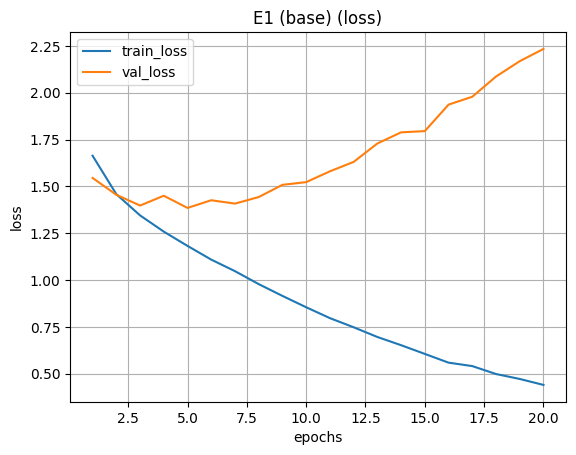

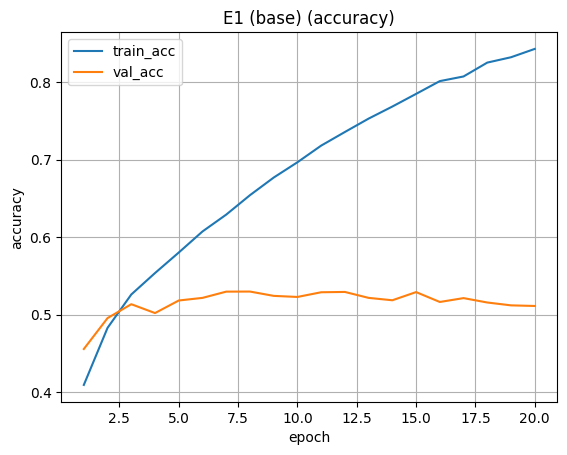

In [42]:
set_seed(42)
baseline = MLP(hidden_dims=(256, 128), dropout_p=0.0, use_batchnorm=False).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(baseline.parameters(), lr=1e-3)

history_baseline = fit(
    baseline, train_loader, val_loader,
    optimizer, criterion, device,
    epochs=20,
    early_stopping=None
)

plot_history(history_baseline, title="E1 (base)")

## E2

epoch 01/20 | train loss=1.7505, acc=0.3797 | val loss=1.5801, acc=0.4383
epoch 02/20 | train loss=1.5836, acc=0.4410 | val loss=1.5247, acc=0.4553
epoch 03/20 | train loss=1.5110, acc=0.4635 | val loss=1.4576, acc=0.4863
epoch 04/20 | train loss=1.4548, acc=0.4842 | val loss=1.4423, acc=0.4881
epoch 05/20 | train loss=1.4088, acc=0.5000 | val loss=1.4021, acc=0.5069
epoch 06/20 | train loss=1.3630, acc=0.5148 | val loss=1.3945, acc=0.5074
epoch 07/20 | train loss=1.3307, acc=0.5258 | val loss=1.3677, acc=0.5198
epoch 08/20 | train loss=1.3033, acc=0.5362 | val loss=1.3664, acc=0.5166
epoch 09/20 | train loss=1.2683, acc=0.5462 | val loss=1.3615, acc=0.5249
epoch 10/20 | train loss=1.2418, acc=0.5547 | val loss=1.3730, acc=0.5217
epoch 11/20 | train loss=1.2204, acc=0.5632 | val loss=1.3409, acc=0.5314
epoch 12/20 | train loss=1.1952, acc=0.5703 | val loss=1.3520, acc=0.5309
epoch 13/20 | train loss=1.1722, acc=0.5799 | val loss=1.3458, acc=0.5293
epoch 14/20 | train loss=1.1542, acc=0

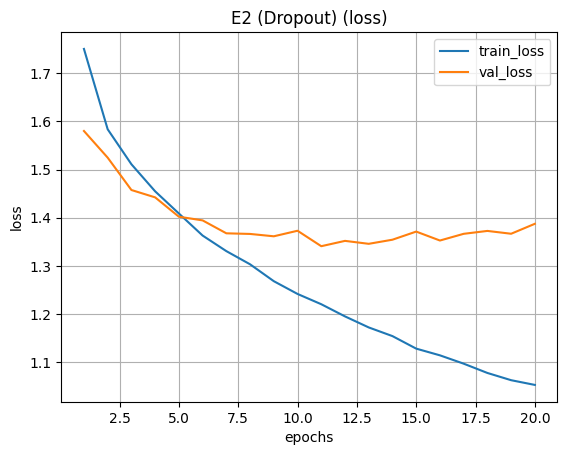

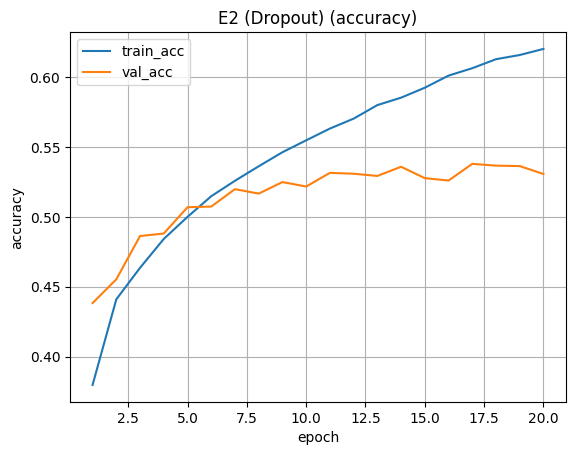

In [43]:
set_seed(42)
dropout_model = MLP(hidden_dims=(256, 128), dropout_p=0.2, use_batchnorm=False).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(dropout_model.parameters(), lr=1e-3)

history_dropout = fit(
    dropout_model, train_loader, val_loader,
    optimizer, criterion, device,
    epochs=20,
    early_stopping=None
)

plot_history(history_dropout, title="E2 (Dropout)")

## E3

epoch 01/20 | train loss=1.6367, acc=0.4167 | val loss=1.4954, acc=0.4662
epoch 02/20 | train loss=1.4249, acc=0.4899 | val loss=1.3832, acc=0.5118
epoch 03/20 | train loss=1.3243, acc=0.5263 | val loss=1.3589, acc=0.5233
epoch 04/20 | train loss=1.2470, acc=0.5567 | val loss=1.3527, acc=0.5168
epoch 05/20 | train loss=1.1795, acc=0.5793 | val loss=1.2967, acc=0.5424
epoch 06/20 | train loss=1.1207, acc=0.5999 | val loss=1.3148, acc=0.5365
epoch 07/20 | train loss=1.0637, acc=0.6230 | val loss=1.3410, acc=0.5397
epoch 08/20 | train loss=1.0147, acc=0.6402 | val loss=1.3220, acc=0.5399
epoch 09/20 | train loss=0.9623, acc=0.6571 | val loss=1.3436, acc=0.5469
epoch 10/20 | train loss=0.9126, acc=0.6735 | val loss=1.3289, acc=0.5464
epoch 11/20 | train loss=0.8661, acc=0.6928 | val loss=1.3653, acc=0.5433
epoch 12/20 | train loss=0.8258, acc=0.7065 | val loss=1.3899, acc=0.5469
epoch 13/20 | train loss=0.7810, acc=0.7224 | val loss=1.4114, acc=0.5503
epoch 14/20 | train loss=0.7450, acc=0

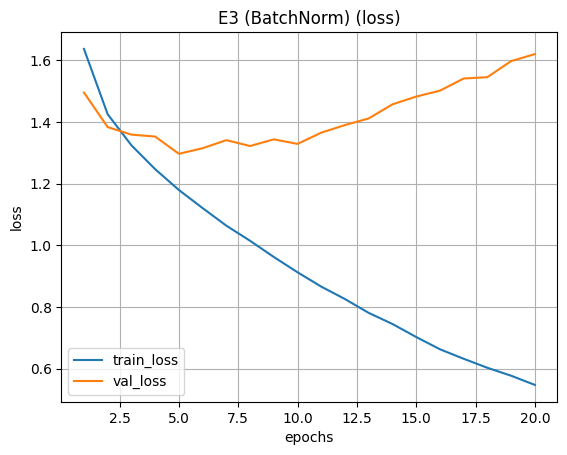

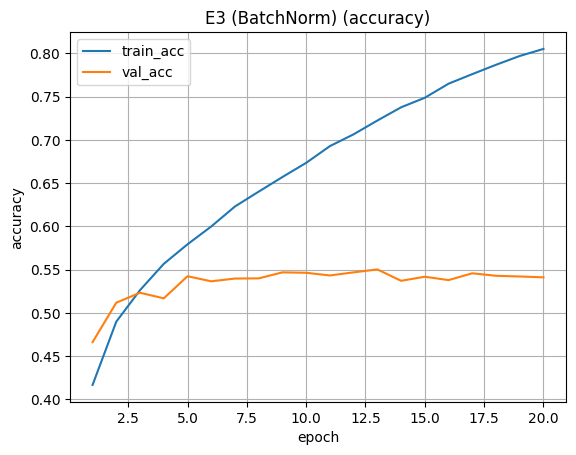

In [44]:
set_seed(42)
batchnorm_model = MLP(hidden_dims=(256, 128), dropout_p=0.0, use_batchnorm=True).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(batchnorm_model.parameters(), lr=1e-3)

history_batchnorm = fit(
    batchnorm_model, train_loader, val_loader,
    optimizer, criterion, device,
    epochs=20,
    early_stopping=None
)

plot_history(history_batchnorm, title="E3 (BatchNorm)")

## E4

epoch 01/50 | train loss=1.6367, acc=0.4167 | val loss=1.4954, acc=0.4662
epoch 02/50 | train loss=1.4249, acc=0.4899 | val loss=1.3832, acc=0.5118
epoch 03/50 | train loss=1.3243, acc=0.5263 | val loss=1.3589, acc=0.5233
epoch 04/50 | train loss=1.2470, acc=0.5567 | val loss=1.3527, acc=0.5168
epoch 05/50 | train loss=1.1795, acc=0.5793 | val loss=1.2967, acc=0.5424
epoch 06/50 | train loss=1.1207, acc=0.5999 | val loss=1.3148, acc=0.5365
epoch 07/50 | train loss=1.0637, acc=0.6230 | val loss=1.3410, acc=0.5397
epoch 08/50 | train loss=1.0147, acc=0.6402 | val loss=1.3220, acc=0.5399
epoch 09/50 | train loss=0.9623, acc=0.6571 | val loss=1.3436, acc=0.5469
epoch 10/50 | train loss=0.9126, acc=0.6735 | val loss=1.3289, acc=0.5464
epoch 11/50 | train loss=0.8661, acc=0.6928 | val loss=1.3653, acc=0.5433
epoch 12/50 | train loss=0.8258, acc=0.7065 | val loss=1.3899, acc=0.5469
epoch 13/50 | train loss=0.7810, acc=0.7224 | val loss=1.4114, acc=0.5503
epoch 14/50 | train loss=0.7450, acc=0

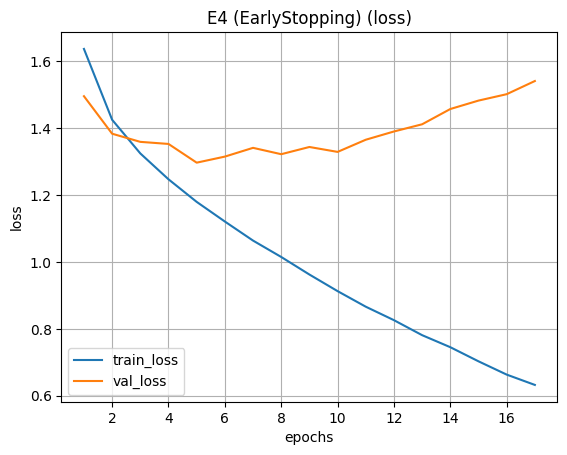

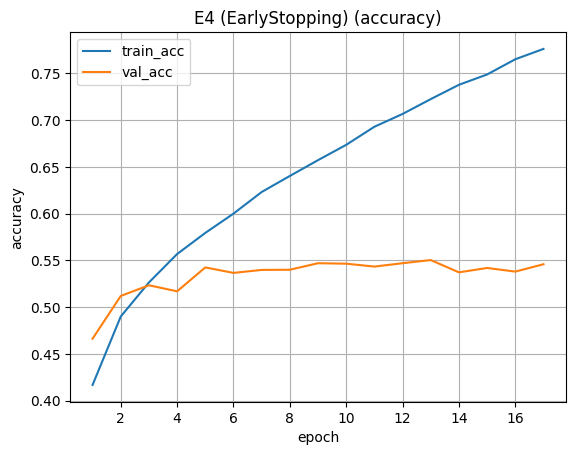

saved: artifacts/figures/curves_best.png


In [45]:
set_seed(42)
es_model = MLP(hidden_dims=(256, 128), dropout_p=0.0, use_batchnorm=True).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(es_model.parameters(), lr=1e-3)

es = EarlyStopping(patience=4, min_delta=0.0005)

history_es = fit(
    es_model, train_loader, val_loader,
    optimizer, criterion, device,
    epochs=50,
    early_stopping=es,
    verbose=True
)

title = "curves_best"
plot_history(history_es, title="E4 (EarlyStopping)", isSave=True, save_title = title)
print("saved: artifacts/figures/curves_best.png")

In [46]:
results = {
    "base": evaluate(baseline, test_loader, nn.CrossEntropyLoss(), device)[1],
    "Dropout": evaluate(dropout_model, test_loader, nn.CrossEntropyLoss(), device)[1],
    "BatchNorm": evaluate(batchnorm_model, test_loader, nn.CrossEntropyLoss(), device)[1],
    "EarlyStopping": evaluate(es_model, test_loader, nn.CrossEntropyLoss(), device)[1],
}

for k, v in results.items():
    print(f"{k:>9}: test_acc={v:.4f}")

     base: test_acc=0.5015
  Dropout: test_acc=0.5254
BatchNorm: test_acc=0.5315
EarlyStopping: test_acc=0.5365


# Часть B

## O1

epoch 01/8 | train loss=1.8608, acc=0.3269 | val loss=1.6968, acc=0.3914
epoch 02/8 | train loss=1.6986, acc=0.3875 | val loss=1.6384, acc=0.4119
epoch 03/8 | train loss=1.6118, acc=0.4244 | val loss=1.5818, acc=0.4417
epoch 04/8 | train loss=1.5641, acc=0.4430 | val loss=1.5478, acc=0.4508
epoch 05/8 | train loss=1.5201, acc=0.4566 | val loss=1.5724, acc=0.4420
epoch 06/8 | train loss=1.4890, acc=0.4696 | val loss=1.5136, acc=0.4657
epoch 07/8 | train loss=1.4554, acc=0.4782 | val loss=1.5026, acc=0.4781
epoch 08/8 | train loss=1.4315, acc=0.4916 | val loss=1.5354, acc=0.4642


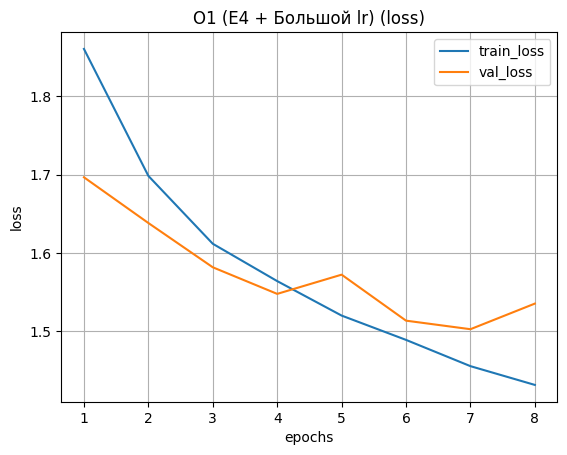

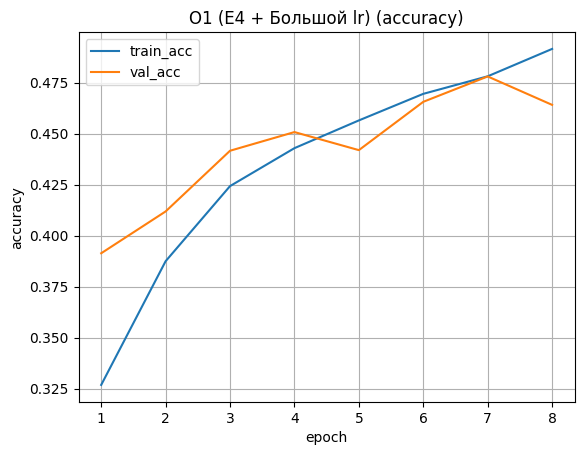

In [47]:
set_seed(42)
o1_model = MLP(hidden_dims=(256, 128), dropout_p=0.0, use_batchnorm=True).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(o1_model.parameters(), lr=1e-1)

es = EarlyStopping(patience=4, min_delta=0.0005)

history_o1 = fit(
    o1_model, train_loader, val_loader,
    optimizer, criterion, device,
    epochs=8,
    early_stopping=es,
    verbose=True
)

plot_history(history_o1, title="O1 (E4 + Большой lr)")

## O2

epoch 01/8 | train loss=1.9892, acc=0.3114 | val loss=1.8412, acc=0.3850
epoch 02/8 | train loss=1.7869, acc=0.4051 | val loss=1.7368, acc=0.4198
epoch 03/8 | train loss=1.7025, acc=0.4340 | val loss=1.6734, acc=0.4411
epoch 04/8 | train loss=1.6439, acc=0.4509 | val loss=1.6311, acc=0.4543
epoch 05/8 | train loss=1.5941, acc=0.4684 | val loss=1.5982, acc=0.4643
epoch 06/8 | train loss=1.5548, acc=0.4800 | val loss=1.5622, acc=0.4705
epoch 07/8 | train loss=1.5156, acc=0.4933 | val loss=1.5397, acc=0.4796
epoch 08/8 | train loss=1.4835, acc=0.5059 | val loss=1.5198, acc=0.4855


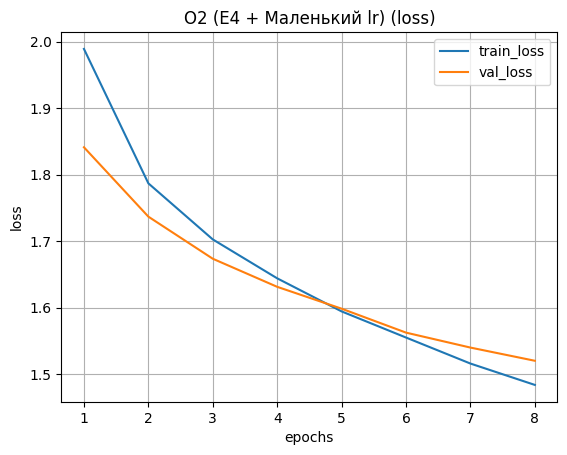

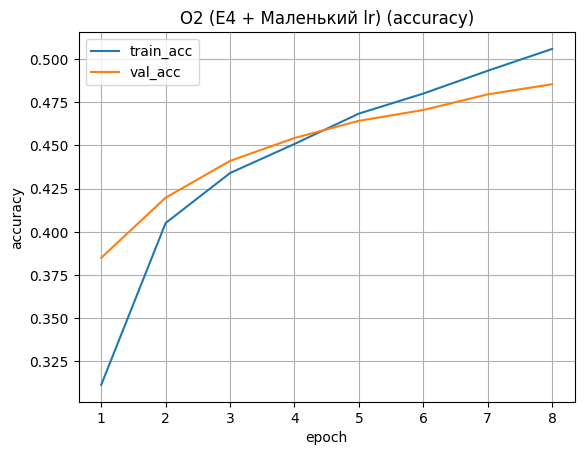

In [48]:
set_seed(42)
o2_model = MLP(hidden_dims=(256, 128), dropout_p=0.0, use_batchnorm=True).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(o2_model.parameters(), lr=1e-5)

es = EarlyStopping(patience=4, min_delta=0.0005)

history_o2 = fit(
    o2_model, train_loader, val_loader,
    optimizer, criterion, device,
    epochs=8,
    early_stopping=es,
    verbose=True
)

plot_history(history_o2, title="O2 (E4 + Маленький lr)")

epoch 01/15 | train loss=1.7399, acc=0.3917 | val loss=1.5687, acc=0.4545
epoch 02/15 | train loss=1.4984, acc=0.4754 | val loss=1.4571, acc=0.4864
epoch 03/15 | train loss=1.3912, acc=0.5128 | val loss=1.4179, acc=0.4995
epoch 04/15 | train loss=1.3173, acc=0.5364 | val loss=1.3952, acc=0.5078
epoch 05/15 | train loss=1.2510, acc=0.5623 | val loss=1.3519, acc=0.5262
epoch 06/15 | train loss=1.1980, acc=0.5792 | val loss=1.3414, acc=0.5286
epoch 07/15 | train loss=1.1496, acc=0.5983 | val loss=1.3329, acc=0.5337
epoch 08/15 | train loss=1.1076, acc=0.6129 | val loss=1.3257, acc=0.5332
epoch 09/15 | train loss=1.0638, acc=0.6274 | val loss=1.3394, acc=0.5361
epoch 10/15 | train loss=1.0212, acc=0.6448 | val loss=1.3357, acc=0.5368
epoch 11/15 | train loss=0.9861, acc=0.6582 | val loss=1.3247, acc=0.5428
epoch 12/15 | train loss=0.9511, acc=0.6660 | val loss=1.3562, acc=0.5347
epoch 13/15 | train loss=0.9170, acc=0.6818 | val loss=1.3512, acc=0.5345
epoch 14/15 | train loss=0.8837, acc=0

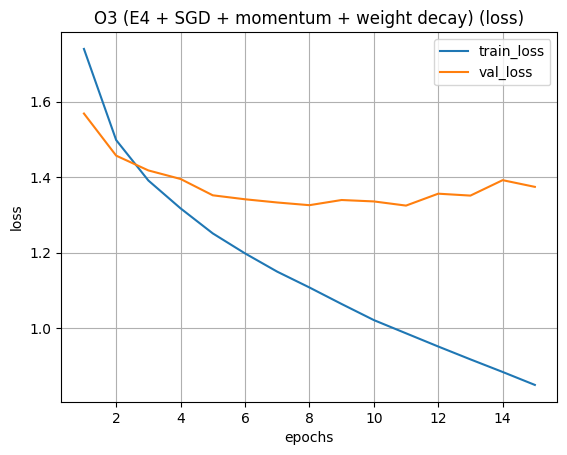

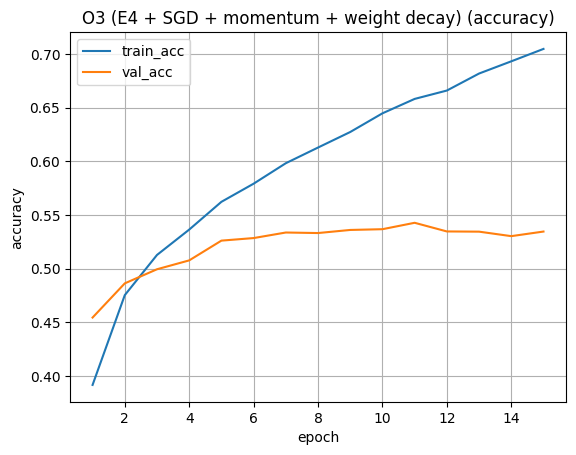

In [49]:
set_seed(42)
o3_model = MLP(hidden_dims=(256, 128), dropout_p=0.0, use_batchnorm=True).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(o3_model.parameters(), lr=1e-3, momentum=0.9, weight_decay=1e-4)

es = EarlyStopping(patience=4, min_delta=0.0005)

history_o3 = fit(
    o3_model, train_loader, val_loader,
    optimizer, criterion, device,
    epochs=15,
    early_stopping=es,
    verbose=True
)

plot_history(history_o3, title="O3 (E4 + SGD + momentum + weight decay)")

# Артефакты

In [50]:
results = [
    {
        'experiment_id': 'E1',
        'dataset': 'CIFAR10',
        'seed': 42,
        'model_summary': '256, 128 / ReLU / 0.0 / False',
        'optimizer': 'Adam',
        'lr': 1e-3,
        'momentum': 0,
        'weight_decay': 0,
        'epochs_trained': 20,
        'best_val_accuracy': 0.5299,
        'best_val_loss': 1.3852
    },
    {
        'experiment_id': 'E2',
        'dataset': 'CIFAR10',
        'seed': 42,
        'model_summary': '256, 128 / ReLU / 0.2 / False',
        'optimizer': 'Adam',
        'lr': 1e-3,
        'momentum': 0,
        'weight_decay': 0,
        'epochs_trained': 20,
        'best_val_accuracy': 0.5379,
        'best_val_loss': 1.3409
    },
    {
        'experiment_id': 'E3',
        'dataset': 'CIFAR10',
        'seed': 42,
        'model_summary': '256, 128 / ReLU / 0.0 / True',
        'optimizer': 'Adam',
        'lr': 1e-3,
        'momentum': 0,
        'weight_decay': 0,
        'epochs_trained': 20,
        'best_val_accuracy': 0.5503,
        'best_val_loss': 1.2967
    },
    {
        'experiment_id': 'E4',
        'dataset': 'CIFAR10',
        'seed': 42,
        'model_summary': '256, 128 / ReLU / 0.0 / True',
        'optimizer': 'Adam',
        'lr': 1e-3,
        'momentum': 0,
        'weight_decay': 0,
        'epochs_trained': 17,
        'best_val_accuracy': 0.5503,
        'best_val_loss': 1.2967
    },
    {
        'experiment_id': 'O1',
        'dataset': 'CIFAR10',
        'seed': 42,
        'model_summary': '256, 128 / ReLU / 0.0 / True',
        'optimizer': 'Adam',
        'lr': 1e-1,
        'momentum': 0,
        'weight_decay': 0,
        'epochs_trained': 8,
        'best_val_accuracy': 0.4781,
        'best_val_loss': 1.5026
    },
    {
        'experiment_id': 'O2',
        'dataset': 'CIFAR10',
        'seed': 42,
        'model_summary': '256, 128 / ReLU / 0.0 / True',
        'optimizer': 'Adam',
        'lr': 1e-5,
        'momentum': 0,
        'weight_decay': 0,
        'epochs_trained': 8,
        'best_val_accuracy': 0.4855,
        'best_val_loss': 1.5198
    },
    {
        'experiment_id': 'O3',
        'dataset': 'CIFAR10',
        'seed': 42,
        'model_summary': '256, 128 / ReLU / 0.0 / True',
        'optimizer': 'SGD',
        'lr': 1e-3,
        'momentum': 0.9,
        'weight_decay': 1e-4,
        'epochs_trained': 15,
        'best_val_accuracy': 0.5428,
        'best_val_loss': 1.3247
    },
]

output_path = './artifacts/runs.csv'
pd.DataFrame(results).to_csv(output_path, index=False, encoding='utf-8')


In [56]:
def save_json(obj: dict, path: Path):
    path.parent.mkdir(parents=True, exist_ok=True)
    with path.open("w", encoding="utf-8") as f:
        json.dump(obj, f, ensure_ascii=False, indent=2)


ARTIFACTS_DIR = Path("artifacts")

best_config = {
    "experiment_id": "E4",
    "dataset": "CIFAR10",
    "seed": 42,
    "hidden_sizes": [256, 128],
    "activation": "ReLU",
    "dropout": 0.0,
    "batchnorm": True,
    "optimizer": "Adam",
    "lr": 0.001,
    "batch_size": 64,
    "epochs": 50,
    "momentum": 0,
    "weight_decay": 0,
    "best_val_accuracy": 0.5503,
    "best_val_loss": 1.2967
}

save_json(best_config, ARTIFACTS_DIR / "best_config.json")
print("saved: artifacts/best_config.json")

saved: artifacts/best_config.json


saved: artifacts/figures/curves_lr_extremes.png


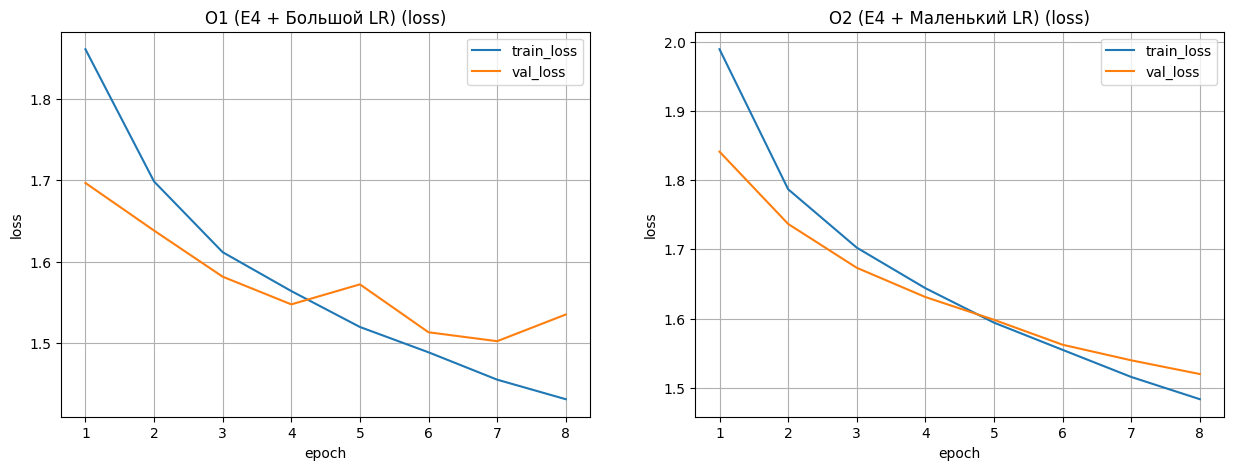

In [52]:
title = "curves_lr_extremes"
plot_history_double(history_o1, history_o2, title="O1 (E4 + Большой LR)", title2="O2 (E4 + Маленький LR)", isSave=True, save_title = title)
print("saved: artifacts/figures/curves_lr_extremes.png")

In [53]:
path = './artifacts/best_model.pt'
torch.save(es_model.state_dict(), path)

In [54]:
print("Artifacts saved:")
print(" + artifacts/best_model.pt")
print(" + artifacts/best_config.json")
print(" + artifacts/runs.csv")
print(" + artifacts/figures/curves_best.png")
print(" + artifacts/figures/curves_lr_extremes.png")

Artifacts saved:
 + artifacts/best_model.pt
 + artifacts/best_config.json
 + artifacts/runs.csv
 + artifacts/figures/curves_best.png
 + artifacts/figures/curves_lr_extremes.png
